In [13]:
import pandas as pd
import numpy as np
import pickle
import json

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


In [14]:
import seaborn as sns
import scienceplots

In [15]:
sample_color = '#8B4513'  # Brown

In [16]:
detector_color = "#332288"  # Red
shield_color = '#88CCEE'    # Blue
lead_color = '#44AA99'      # Teal
ba_color = '#117733'        # Green
al_color = '#999933'        # Purple
wheel_color = '#DDCC77'     # Orange
fe_color = '#CC6677'        # Grey

In [17]:
min_width = 30 / 25.4
single_col_width = 90 / 25.4
one_half_col_width = 140 / 25.4
double_col_width = 190 / 25.4

In [18]:
plt.style.use('science')
plt.rcParams['figure.figsize'] = [2*3.54, 2*3.54]
dpi = 300 
plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi'] = 100  
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [19]:
bbbbbox = dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, edgecolor='gray', linewidth=0.5)

def plot_box(ax, xmin, xmax, ymin, ymax, zmin, zmax, color, alpha=1, label=None, zorder=None):
    # Draw a rectangular box (RPP)
    x = [xmin, xmax]
    y = [ymin, ymax]
    z = [zmin, zmax]# Draw edges
    for s, e in [
        # bottom
        ([x[0], y[0], z[0]], [x[1], y[0], z[0]]),
        ([x[1], y[0], z[0]], [x[1], y[1], z[0]]),
        ([x[1], y[1], z[0]], [x[0], y[1], z[0]]),
        ([x[0], y[1], z[0]], [x[0], y[0], z[0]]),
        # top
        ([x[0], y[0], z[1]], [x[1], y[0], z[1]]),
        ([x[1], y[0], z[1]], [x[1], y[1], z[1]]),
        ([x[1], y[1], z[1]], [x[0], y[1], z[1]]),
        ([x[0], y[1], z[1]], [x[0], y[0], z[1]]),
        # sides
        ([x[0], y[0], z[0]], [x[0], y[0], z[1]]),
        ([x[1], y[0], z[0]], [x[1], y[0], z[1]]),
        ([x[1], y[1], z[0]], [x[1], y[1], z[1]]),
        ([x[0], y[1], z[0]], [x[0], y[1], z[1]])
    ]:
        ax.plot3D(*zip(s, e), color=color, alpha=alpha, zorder=zorder, linewidth=1.2)
    # Draw faces
    faces = [
        # bottom
        [[x[0], y[0], z[0]], [x[1], y[0], z[0]], [x[1], y[1], z[0]], [x[0], y[1], z[0]]],
        # top
        [[x[0], y[0], z[1]], [x[1], y[0], z[1]], [x[1], y[1], z[1]], [x[0], y[1], z[1]]],
        # front
        [[x[0], y[0], z[0]], [x[1], y[0], z[0]], [x[1], y[0], z[1]], [x[0], y[0], z[1]]],
        # back
        [[x[0], y[1], z[0]], [x[1], y[1], z[0]], [x[1], y[1], z[1]], [x[0], y[1], z[1]]],
        # left
        [[x[0], y[0], z[0]], [x[0], y[1], z[0]], [x[0], y[1], z[1]], [x[0], y[0], z[1]]],
        # right
        [[x[1], y[0], z[0]], [x[1], y[1], z[0]], [x[1], y[1], z[1]], [x[1], y[0], z[1]]]
    ]
    poly3d = Poly3DCollection(faces, facecolors=color, alpha=alpha, zorder=zorder, linewidths=0.5, edgecolors='k')
    ax.add_collection3d(poly3d)
    if label:
        ax.text((xmin+xmax)/2, (ymin+ymax)/2, (zmin+zmax)/2, label, color='black', zorder=1e9, bbox=bbbbbox, fontsize=10, ha='center', fontweight='bold')


def plot_cylinder(ax, base, vec, radius, height, color, alpha=1, label=None, zorder=None):
    # Draw a cylinder (RCC) with flat ends
    x0, y0, z0 = base
    dx, dy, dz = vec
    # Normalize direction vector
    length = np.sqrt(dx**2 + dy**2 + dz**2)
    if length == 0:
        return
    dx, dy, dz = dx/length, dy/length, dz/length
    # Create cylinder along z, then rotate
    z = np.linspace(0, height, 30)
    theta = np.linspace(0, 2*np.pi, 30)
    theta_grid, z_grid = np.meshgrid(theta, z)
    x_grid = radius * np.cos(theta_grid)
    y_grid = radius * np.sin(theta_grid)
    # Build rotation matrix
    v = np.array([dx, dy, dz])
    v0 = np.array([0, 0, 1])
    if not np.allclose(v, v0):
        axis = np.cross(v0, v)
        angle = np.arccos(np.clip(np.dot(v0, v), -1.0, 1.0))
        K = np.array([[0, -axis[2], axis[1]],
                      [axis[2], 0, -axis[0]],
                      [-axis[1], axis[0], 0]])
        R = np.eye(3) + np.sin(angle)*K + (1-np.cos(angle))*(K@K)
        xyz = np.stack([x_grid.flatten(), y_grid.flatten(), z_grid.flatten()])
        xyz_rot = R @ xyz
        x_grid = xyz_rot[0].reshape(x_grid.shape)
        y_grid = xyz_rot[1].reshape(y_grid.shape)
        z_grid = xyz_rot[2].reshape(z_grid.shape)
    x_grid += x0
    y_grid += y0
    z_grid += z0
    ax.plot_surface(x_grid, y_grid, z_grid, color=color, alpha=alpha, linewidth=0, shade=True, zorder=zorder)

    # Flat ends
    for zc in [0, height]:
        # Circle in xy-plane
        x_end = radius * np.cos(theta)
        y_end = radius * np.sin(theta)
        z_end = np.full_like(x_end, zc)
        # Rotate
        xyz_end = np.stack([x_end, y_end, z_end])
        if not np.allclose(v, v0):
            xyz_end = R @ xyz_end
        x_end = xyz_end[0] + x0
        y_end = xyz_end[1] + y0
        z_end = xyz_end[2] + z0
        # Use Poly3DCollection for flat ends
        verts = [list(zip(x_end, y_end, z_end))]
        poly = Poly3DCollection(verts, facecolors=color, alpha=alpha, zorder=zorder)
        ax.add_collection3d(poly)

    if label:
        ax.text(x0+radius+2, y0, z0, label, color='black', bbox=bbbbbox, fontsize=10, ha='left', fontweight='bold')

def plot_cone(ax, pos, vec, dir, length, color='red', alpha=1, label=None, zorder=None):
    """
    Draw a cone with end point at pos, pointing in direction vec, with angle from dir
    """
    x0, y0, z0 = pos
    dx, dy, dz = vec
    # Normalize direction vector
    norm = np.sqrt(dx**2 + dy**2 + dz**2)
    if norm == 0:
        return
    dx, dy, dz = dx/norm, dy/norm, dz/norm
    # Create cone base circle
    theta = np.linspace(0, 2*np.pi, 30)
    r = length * np.tan(np.radians(dir))
    x_circle = r * np.cos(theta)
    y_circle = r * np.sin(theta)
    z_circle = np.zeros_like(x_circle)
    # Rotate circle to point in direction vec
    v0 = np.array([0, 0, 1])
    v = np.array([dx, dy, dz])
    if not np.allclose(v, v0):
        axis = np.cross(v0, v)
        angle = np.arccos(np.clip(np.dot(v0, v), -1.0, 1.0))
        K = np.array([[0, -axis[2], axis[1]],
                      [axis[2], 0, -axis[0]],
                      [-axis[1], axis[0], 0]])
        R = np.eye(3) + np.sin(angle)*K + (1-np.cos(angle))*(K@K)
        xyz = np.stack([x_circle.flatten(), y_circle.flatten(), z_circle.flatten()])
        xyz_rot = R @ xyz
        x_circle = xyz_rot[0].reshape(x_circle.shape)
        y_circle = xyz_rot[1].reshape(y_circle.shape)
        z_circle = xyz_rot[2].reshape(z_circle.shape)
    x_circle += x0 + dx * length
    y_circle += y0 + dy * length
    z_circle += z0 + dz * length
    # Draw cone surface
    for i in range(len(x_circle)):
        ax.plot([x0, x_circle[i]], [y0, y_circle[i]], [z0, z_circle[i]], color=color, alpha=alpha, zorder=zorder, linewidth=0.8)
    if label:
        ax.text(x0-30, y0+50, z0 + dz * length / 2, label, color='black', bbox=bbbbbox, fontsize=10, ha='left', fontweight='bold', zorder=1e9)
    


def plot_detector_and_emitter(ax):
    plot_cylinder(ax, base=(56, -5.0, -1.0), vec=(0.0, 20.3, 0.0), radius=4.5, height=20.3, color='red', alpha=1, label='Detector')
    
def plot_MCNP(ax, zorder=100000):
    # Define better colors


    # Detector (surface 21)
    plot_cylinder(ax, base=(56, -5.0, -1.0), vec=(0.0, 20.3, 0.0), radius=4.5, height=20.3, color=detector_color, alpha=1, zorder=zorder+1)
    ax.text(56, 15.5, -10, 'Detector', color=detector_color, bbox=bbbbbox, fontsize=10, ha='center', fontweight='bold', zorder=1e9)

    # Shielding boxes (RPPs)
    plot_box(ax, 19, 29, -7.5, 7.5, -11, 9, color=shield_color, alpha=1, 
            #  label='PbPE', 
             zorder=zorder)
    plot_box(ax, 9, 19, 4, 9, -11, 9, color=lead_color, alpha=1, 
            #  label='Pb',
            #  label='Shielding',
             zorder=zorder)
    plot_box(ax, 9, 19, -9, -4, -11, 9, color=lead_color, alpha=1, 
             zorder=zorder)
    plot_box(ax, 19, 29, 7.5, 12.5, -11, 9, color=lead_color, alpha=1, 
             zorder=zorder)
    plot_box(ax, 19, 29, -12.5, -7.5, -11, 9, color=lead_color, alpha=1, 
             zorder=zorder)
    plot_box(ax, 29, 34, -15, 15, -11, 9, color=lead_color, alpha=1, 
             zorder=zorder)
    plot_box(ax, 9, 19, -4, 4, 4, 9, color=lead_color, alpha=1, 
             zorder=zorder)
    plot_box(ax, -26, 26, 18, 28, -11, 9, color=ba_color, alpha=1, 
            #  label='BA1', 
             zorder=zorder)
    plot_box(ax, -26, 26, -28, -18, -11, 9, color=ba_color, alpha=1, 
            #  label='BA2', 
             zorder=zorder)
    plot_box(ax, -65, 65, -28, 28, 10, 10.5, color=al_color, alpha=1, 
            #  label='Al', 
             zorder=zorder)
    plot_box(ax, -27, 27, 29, 34, -11, 9, color=fe_color, alpha=1, 
            #  label='Fe1', 
             zorder=zorder)
    plot_box(ax, -27, 27, -34, -29, -11, 9, color=fe_color, alpha=1, 
            #  label='Fe2', 
             zorder=zorder)
    ax.text(20, 0, -5, 'Shielding', color='black', bbox=bbbbbox, fontsize=10, ha='center', fontweight='bold', zorder=1e9)

    # Wheels (outer treads only for clarity)
    # plot_cylinder(ax, base=(-2, 77, 8), vec=(0, 25, 0), radius=29, height=25, color=wheel_color, alpha=0.3, label='Wheel 1', zorder=zorder)
    # plot_cylinder(ax, base=(68, 77, 8), vec=(0, 25, 0), radius=29, height=25, color=wheel_color, alpha=0.3, label='Wheel 2', zorder=zorder)
    plot_cylinder(ax, base=(-2, 77, 8), vec=(0, -25, 0), radius=29, height=25, color=wheel_color, alpha=1, zorder=-1e200)
    plot_cylinder(ax, base=(68, 77, 8), vec=(0, -25, 0), radius=29, height=25, color=wheel_color, alpha=1, zorder=-1e200)
    
    plot_cylinder(ax, base=(-20, 0, 0), vec=(38, 0, 0), radius=3.81, height=38, color=fe_color, alpha=0.7, zorder=zorder)
    
    ax.text(80, -100, 18, 'Wheels', color='black', bbox=bbbbbox, fontsize=10, ha='center', fontweight='bold', zorder=1e9)

In [20]:
def soil_on_ax(ax):
    """Enhanced soil visualization with better styling"""
    plot_box(ax, -75, 125, -100, 100, 42-5.5, 42+50-5.5, 
                  color='#8B4513', alpha=0.3, 
                #   label='Soil', 
                  zorder=1)  # Better brown color


In [21]:

def extra(ax):
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')
    ax.set_zlabel('Z (cm)')
    ax.set_proj_type('ortho')
    ax.invert_zaxis()

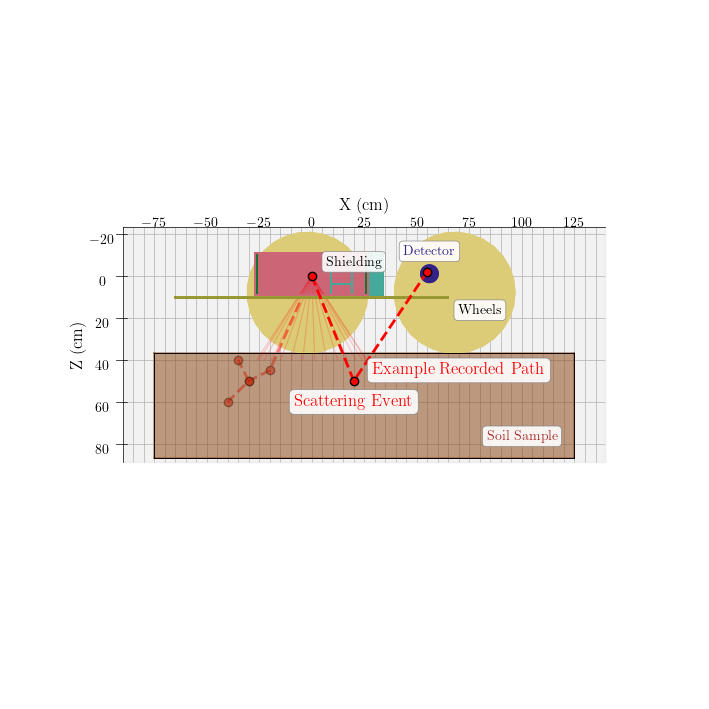

In [22]:
mod=1
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=[3*3.54*mod, 2*3.54*mod], layout='constrained')
# fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=[single_col_width, single_col_width], layout='constrained')
# plt.title('MCNP Geometry (side)', y=.83)

plot_MCNP(ax)
plot_cone(ax, pos=(0, 0, 0), vec=(0.0, 0, 1.0), dir=np.degrees(np.cos(.95)), length=40, color='red', alpha=.1, zorder=2000)

soil_on_ax(ax)
extra(ax)

# draw line segment from (0,0,0) to (20,0,60)
xs, ys, zs = [0, 20, 55], [0, 0, 0], [0, 50, -2]
ax.plot(xs, ys, zs, color='red', linewidth=2, linestyle='--', marker='o', markersize=6, markeredgecolor='k', markerfacecolor='red', zorder=1e9)
ax.text(70, 0, 45, 'Example Recorded Path', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.text(xs[1], ys[1], zs[1]+10, 'Scattering Event', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)

xs, ys, zs = [0, -20, -30, -40], [0, 0, 0, 0], [0, 45, 50, 60]
ax.plot(xs, ys, zs, color='red', linewidth=2, linestyle='--', marker='o', markersize=6, markeredgecolor='k', markerfacecolor='red', zorder=1e1, alpha=0.5)
xs, ys, zs = [-30, -35], [0, 0], [50, 40]
ax.plot(xs, ys, zs, color='red', linewidth=2, linestyle='--', marker='o', markersize=6, markeredgecolor='k', markerfacecolor='red', zorder=1e1, alpha=0.5)
# ax.text(15, 0, 30, 'Example Path', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)
# ax.text(xs[1], ys[1], zs[1]+6, 'Inelastic Scattering Event', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)

ax.text(100, 0, 78, 'Soil Sample', color='brown', zorder=1e9, bbox=bbbbbox, fontsize=10, ha='center', fontweight='bold')

ax.set_yticklabels([])
ax.set_yticks([]) 
ax.set_ylabel('')
# ax.set_xlim3d(-100, 100)
ax.view_init(elev=0, azim=-90,)
ax.set_aspect('equal')
# plt.tight_layout()

plt.savefig('../Figures/Simulation/MCNPGeometry.png', dpi=100, bbox_inches='tight')
plt.savefig('../Figures/Simulation/MCNPGeometry.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
def plot_MCNP(ax, zorder=100000):

    # Detector (surface 21)
    plot_cylinder(ax, base=(56, -5.0, -1.0), vec=(0.0, 20.3, 0.0), radius=4.5, height=20.3, color=detector_color, alpha=0.9, zorder=zorder+1)
#     ax.text(56, 0, -10, 'Detector', color=detector_color, bbox=bbbbbox, fontsize=10, ha='center', fontweight='bold', zorder=1e9)

    # Shielding boxes (RPPs)
    plot_box(ax, 19, 29, -7.5, 7.5, -11, 9, color=shield_color, alpha=0.8, 
            #  label='PbPE', 
             zorder=zorder)
    plot_box(ax, 9, 19, 4, 9, -11, 9, color=lead_color, alpha=0.7, 
            #  label='Pb', 
            #  label='Shielding',
             zorder=zorder)
    plot_box(ax, 9, 19, -9, -4, -11, 9, color=lead_color, alpha=0.7, 
             zorder=zorder)
    plot_box(ax, 19, 29, 7.5, 12.5, -11, 9, color=lead_color, alpha=0.7, 
             zorder=zorder)
    plot_box(ax, 19, 29, -12.5, -7.5, -11, 9, color=lead_color, alpha=0.7, 
             zorder=zorder)
    plot_box(ax, 29, 34, -15, 15, -11, 9, color=lead_color, alpha=0.7, 
             zorder=zorder)
    plot_box(ax, 9, 19, -4, 4, 4, 9, color=lead_color, alpha=0.7, 
             zorder=zorder)
    plot_box(ax, -26, 26, 18, 28, -11, 9, color=ba_color, alpha=0.7, 
            #  label='BA1', 
             zorder=zorder)
    plot_box(ax, -26, 26, -28, -18, -11, 9, color=ba_color, alpha=0.7, 
            #  label='BA2', 
             zorder=zorder)
    plot_box(ax, -65, 65, -28, 28, 10, 10.5, color=al_color, alpha=0.8, 
            #  label='Al', 
             zorder=zorder)
    plot_box(ax, -27, 27, 29, 34, -11, 9, color=fe_color, alpha=0.7, 
            #  label='Fe1', 
             zorder=zorder)
    plot_box(ax, -27, 27, -34, -29, -11, 9, color=fe_color, alpha=0.7, 
            #  label='Fe2', 
             zorder=zorder)
#     ax.text(20, 0, -5, 'Shielding', color=shield_color, bbox=bbbbbox, fontsize=10, ha='center', fontweight='bold', zorder=1e9)

    # Wheels (outer treads only for clarity)
    plot_cylinder(ax, base=(-2, 77, 8), vec=(0, 25, 0), radius=29, height=25, color=wheel_color, alpha=1, zorder=zorder)
    plot_cylinder(ax, base=(68, 77, 8), vec=(0, 25, 0), radius=29, height=25, color=wheel_color, alpha=1, zorder=zorder)
    plot_cylinder(ax, base=(-2, -77, 8), vec=(0, -25, 0), radius=29, height=25, color=wheel_color, alpha=1, zorder=zorder)
    plot_cylinder(ax, base=(68, -77, 8), vec=(0, -25, 0), radius=29, height=25, color=wheel_color, alpha=1, zorder=zorder)
    
    plot_cylinder(ax, base=(-20, 0, 0), vec=(38, 0, 0), radius=3.81, height=38, color=fe_color, alpha=0.7, zorder=zorder)
    
#     ax.text(70, -90, 18, 'Wheels', color=wheel_color, bbox=bbbbbox, fontsize=10, ha='center', fontweight='bold', zorder=1e9)


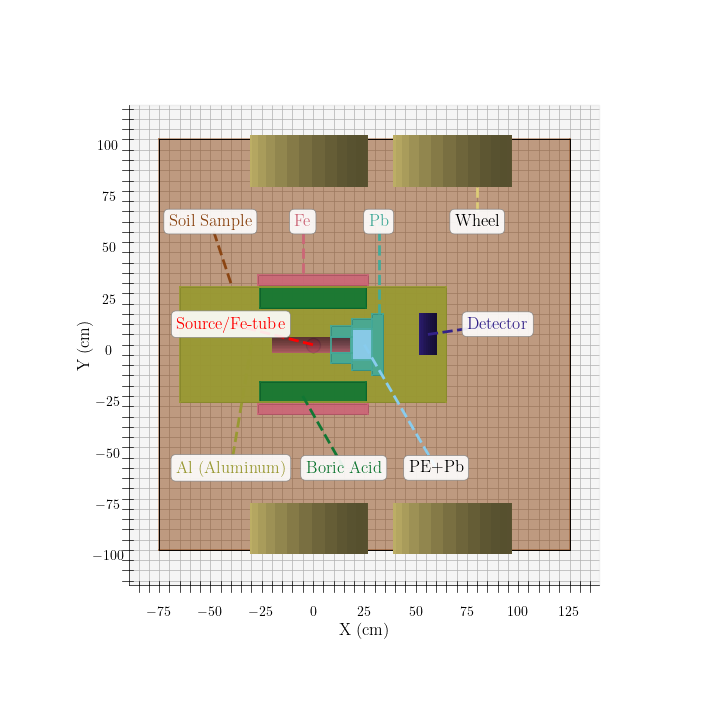

In [24]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=[3*3.54, 2*3.54], layout='constrained')
# plt.title('MCNP Geometry (Top)', y=1)

plot_MCNP(ax)
# plot_cone(ax, pos=(0, 0, 0), vec=(0.0, 0, 1.0), dir=np.degrees(np.cos(.95)), length=40, color='red', alpha=.1, zorder=2)
ax.scatter(0, 0, 0, color='red', s=100, zorder=1e20, alpha=1, edgecolor='k')
soil_on_ax(ax)
extra(ax)

# # draw line segment from (0,0,0) to (20,0,60)
# xs, ys, zs = [0, 20, 55], [0, 0, 0], [0, 50, -2]
# ax.plot(xs, ys, zs, color='red', linewidth=2, linestyle='--', marker='o', markersize=6, markeredgecolor='k', markerfacecolor='red', zorder=1e9)
# ax.text(25, 0, 30, 'Example Recorded Path', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)
# ax.text(xs[1], ys[1], zs[1]+8, 'Scattering Event', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)

# xs, ys, zs = [0, -20, -30, -40], [0, 0, 0, 0], [0, 45, 50, 60]
# ax.plot(xs, ys, zs, color='red', linewidth=2, linestyle='--', marker='o', markersize=6, markeredgecolor='k', markerfacecolor='red', zorder=1e1, alpha=0.5)
# xs, ys, zs = [-30, -35], [0, 0], [50, 40]
# ax.plot(xs, ys, zs, color='red', linewidth=2, linestyle='--', marker='o', markersize=6, markeredgecolor='k', markerfacecolor='red', zorder=1e1, alpha=0.5)
# # ax.text(15, 0, 30, 'Example Path', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)
# # ax.text(xs[1], ys[1], zs[1]+6, 'Inelastic Scattering Event', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)

# plt.tight_layout()
legend_elements = [
    Line2D([0], [0], color=shield_color, lw=6, label='PE+Pb (Shielding)'),
    Line2D([0], [0], color=lead_color, lw=6, label='Pb (Lead)'),
    Line2D([0], [0], color=ba_color, lw=6, label='Boric Acid'),
    Line2D([0], [0], color=al_color, lw=6, label='Al (Aluminum)'),
    Line2D([0], [0], color=fe_color, lw=6, label='Fe'),
    Line2D([0], [0], color=detector_color, lw=6, label='Detector'),
    Line2D([0], [0], color=wheel_color, lw=6, label='Wheel'),
    Line2D([0], [0], color=sample_color, lw=6, label='Soil Sample'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Source'),
]

# label placement
ax.text(-40, 10, -20, 'Source/Fe-tube', color='red', bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([0, -40], [0, 10], [-5, -20], color='red', linewidth=2, linestyle='--', zorder=1e9)

ax.text(90, 10, 0, 'Detector', color=detector_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([56, 90], [5, 10], [0, 0], color=detector_color, linewidth=2, linestyle='--', zorder=1e9)

ax.text(80, 60, 50, 'Wheel', 
        # color=wheel_color, 
        color='black', 
        bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([80, 80], [77, 60], [20, 50], color=wheel_color, linewidth=2, linestyle='--', zorder=1e9)

# ax.text(-40, -60, 60, 'Wheel', color=wheel_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
# ax.plot([0, -40], [-77, -60], [20, 60], color=wheel_color, linewidth=2, linestyle='--', zorder=1e9)

# ax.text(-40, -60, 60, 'Wheel', color=wheel_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
# ax.plot([0, -40], [-77, -60], [20, 60], color=wheel_color, linewidth=2, linestyle='--', zorder=1e9)

# ax.text(-40, -60, 60, 'Wheel', color=wheel_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
# ax.plot([0, -40], [-77, -60], [20, 60], color=wheel_color, linewidth=2, linestyle='--', zorder=1e9)

ax.text(-50, 60, 90, 'Soil Sample', color=sample_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([-40, -50], [30, 60], [72, 90], color=sample_color, linewidth=2, linestyle='--', zorder=1e9)

ax.text(-40, -60, 0, 'Al (Aluminum)', color=al_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([-30, -40], [0, -60], [10, 0], color=al_color, linewidth=2, linestyle='--', zorder=1e9)

ax.text(-5, 60, -10, 'Fe', color=fe_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([-5, -5], [35, 60], [0, -10], color=fe_color, linewidth=2, linestyle='--', zorder=1e9)

ax.text(15, -60, -10, 'Boric Acid', color=ba_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([-5, 15], [-25, -60], [0, -10], color=ba_color, linewidth=2, linestyle='--', zorder=1e9)

ax.text(32, 60, 20, 'Pb', color=lead_color, bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([32, 32], [15, 60], [0, 20], color=lead_color, linewidth=2, linestyle='--', zorder=1e9)

ax.text(
    60, -60, 30, 'PE+Pb', 
    # color=shield_color, 
    color='black', 
    bbox=bbbbbox, ha='center', va='center', zorder=1e10)
ax.plot([25, 60], [0, -60], [0, 20], color=shield_color, linewidth=2, linestyle='--', zorder=1e9)

ax.set_zticklabels([])
ax.set_zticks([]) 
ax.set_zlabel('')
ax.view_init(elev=90, azim=-90,)
ax.set_aspect('equal')

# ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, .7), borderaxespad=0., frameon=True)

plt.savefig('../Figures/Simulation/top.png', dpi=300, bbox_inches='tight')
plt.show()